In [1]:
import pandas as pd
import numpy as np
import json
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

y_train = y_train.squeeze()
y_test = y_test.squeeze()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (96, 3)
X_test : (24, 3)
y_train: (96,)
y_test : (24,)


In [3]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully")

Linear Regression model trained successfully


In [4]:
y_pred_train = model.predict(X_train)

y_pred_test = model.predict(X_test)

print("Predictions generated")

Predictions generated


In [5]:
mae = mean_absolute_error(y_test, y_pred_test)

mse = mean_squared_error(y_test, y_pred_test)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_test)

print("MAE :", round(mae, 3))
print("MSE :", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("R²  :", round(r2, 3))

MAE : 0.978
MSE : 1.293
RMSE: 1.137
R²  : 0.01


In [6]:
metrics = {
    "MAE": float(mae),
    "MSE": float(mse),
    "RMSE": float(rmse),
    "R2": float(r2)
}

with open("../reports/linear_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("Metrics saved successfully")

Metrics saved successfully


In [7]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

coef_df

,Feature,Coefficient
0,temperature,0.087840
1,humidity,-0.214397
2,co2,-0.127668


In [8]:
joblib.dump(model, "../models/linear_regression.joblib")

print("Model saved successfully")

Model saved successfully


In [9]:
residuals = y_test - y_pred_test

print("Residuals calculated")

Residuals calculated


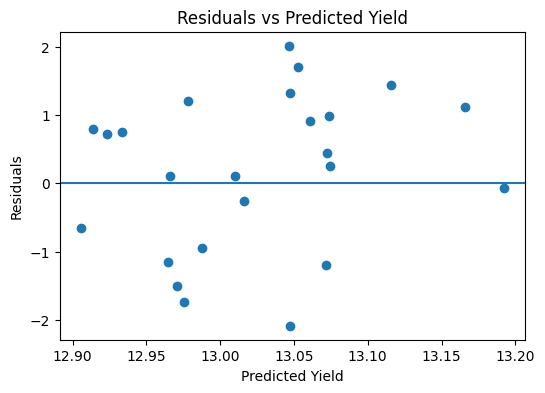

In [12]:
plt.figure(figsize=(6,4))

plt.scatter(y_pred_test, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Yield")

plt.ylabel("Residuals")

plt.title("Residuals vs Predicted Yield")

plt.savefig(
    "../reports/residuals_vs_predicted.png",
    bbox_inches="tight"
)

plt.show()

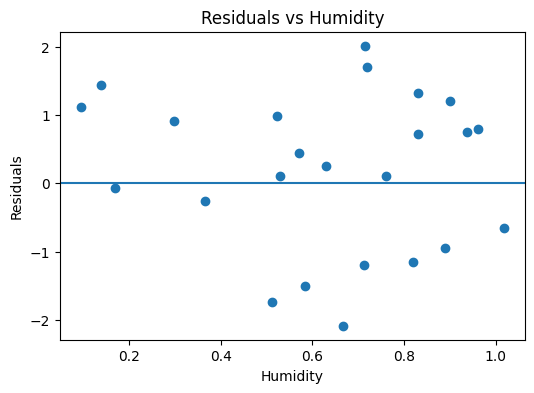

In [13]:
plt.figure(figsize=(6,4))

plt.scatter(X_test["humidity"], residuals)

plt.axhline(y=0)

plt.xlabel("Humidity")

plt.ylabel("Residuals")

plt.title("Residuals vs Humidity")

plt.savefig(
    "../reports/residuals_vs_humidity.png",
    bbox_inches="tight"
)

plt.show()

In [15]:
with open("../reports/linear_diagnostics.md", "w") as f:
    f.write("# Linear Regression Diagnostics\n\n")
    f.write("- Residuals vs Predicted plot generated.\n")
    f.write("- Residuals vs Humidity plot generated.\n")
    f.write("- Linear Regression used as baseline model.\n")
    f.write("- Further comparison with Random Forest recommended.\n")

print("Diagnostics file created")

Diagnostics file created


In [16]:

import os

print(os.listdir("../models"))
print(os.listdir("../reports"))

['.gitkeep', 'scaler.joblib', 'linear_regression.joblib']
['eda_summary.md', 'residuals_vs_predicted.png', 'linear_diagnostics.md', 'cleaning_log.md', 'data_quality.md', 'yield_model.pkl', 'figures', 'linear_metrics.json', 'residuals_vs_humidity.png']


In [17]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

print(coef_df)

       Feature  Coefficient
0  temperature     0.087840
1     humidity    -0.214397
2          co2    -0.127668
